# Final General Anxiety Disorder (GAD) data analysis
The NHIS data was collected by the CDC in America and the gaming data was primarily provided by 18-22 year olds, so the comparisons below follow those guidelines for a more equal comparison.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from my_functions import visualize_count_plot, visualize_and_label_count_plot

conn = sqlite3.connect('../data/mentalhealth.db')

pd.set_option('display.max_columns', None)

## Set Global Variables

In [2]:
colors_ld=['#d7f0fa','#92c5de','#4393c3', '#2166ac', '#5e3c99', '#2d1e2f', '#0f0a14']
colors_dl=['#0f0a14', '#2d1e2f', '#5e3c99', '#2166ac', '#4393c3', '#92c5de', '#d7f0fa']

In [3]:
conn.execute("""
    CREATE TEMP VIEW gad_data_usa_18_22 AS
    SELECT
        p.participant_id,
        p.survey_id,
        p.sex_id,
        p.education_id,
        p.residence,
        p.age,
        p.region_id,
        r.GAD1,
        r.GAD2,
        r.GAD3,
        r.GAD4,
        r.GAD5,
        r.GAD6,
        r.GAD7,
        r.GAD_total,
        r.GAD_cat
    FROM participant p
    JOIN GAD_response r on r.participant_id = p.participant_id
    WHERE p.age BETWEEN 18 AND 22
""")

## How do the total GAD scores compare between gamers and the general population?
- Only USA data
- 18-22 years old
- Show categories on countplots

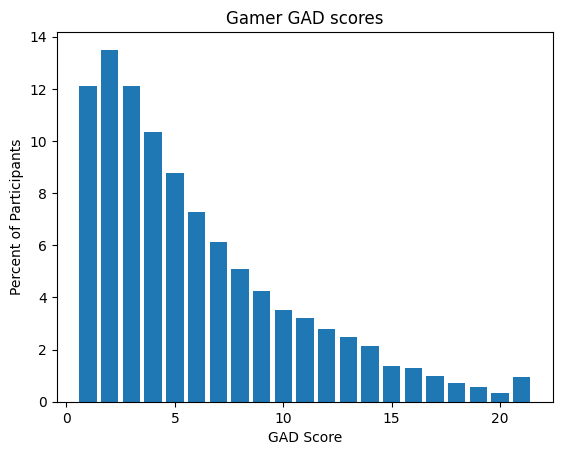

In [23]:
# THIS CODE IS NOT USABLE FOR A SEABORN PLOT


gamer_GAD_scores_query1 = ("""
    SELECT
        GAD_total,
        COUNT(*) as num_participants,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
    FROM gad_data_usa_18_22
    WHERE survey_id = 1 
        AND GAD_total >0
    GROUP BY GAD_total
    ORDER BY GAD_total
""")

gamer_GAD_scores_result1 = pd.read_sql(gamer_GAD_scores_query1, conn, index_col='GAD_total')['percentage']

# I got stuck figuring out how to make the result into a pandas.Series
# ChatGPT walked me through the logic to fix this and to convert the
# total to percentages. I knew I needed a window function, but got 
# stuck in the execution.

visualize_count_plot(gamer_GAD_scores_result1, 'GAD Score', 'Percent of Participants', 'Gamer GAD scores')

In [26]:
gamer_GAD_scores_query2 = ("""
    SELECT
        GAD_total
    FROM gad_data_usa_18_22
    WHERE survey_id = 1
""")


gamer_GAD_scores_result2 = pd.read_sql(gamer_GAD_scores_query2, conn, index_col='GAD_total')


gamer_GAD_scores_result2.head()

""
GAD_total
14
19
0
3
8


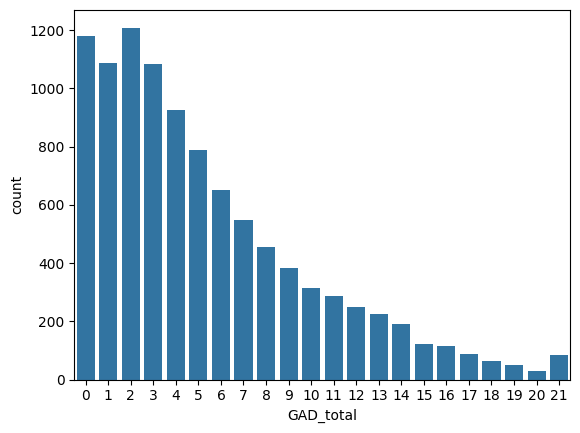

In [27]:
sns.countplot(x='GAD_total', data = gamer_GAD_scores_result2)

plt.show()



In [8]:
gamer_GAD_scores_result

NameError: name 'gamer_GAD_scores_result' is not defined

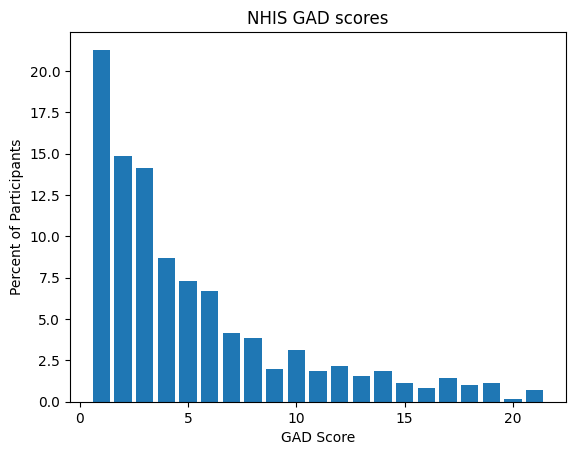

In [ ]:
nhis_GAD_scores_query = ("""
    SELECT
        GAD_total,
        COUNT(*) as num_participants,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
    FROM gad_data_usa_18_22
    WHERE survey_id = 2
        AND GAD_total > 0
    GROUP BY GAD_total
    ORDER BY GAD_total
""")

nhis_GAD_scores_result = pd.read_sql(nhis_GAD_scores_query, conn, index_col='GAD_total')['percentage']

visualize_count_plot(nhis_GAD_scores_result, 'GAD Score', 'Percent of Participants', 'NHIS GAD scores')

### Convert the number of participants to percentage for better comparison on the same plot

## How did the GAD categorizations compare between gamers and the general population?
- Only USA data
- 18-22 years old
- Stacked stem plots?

## How did hours spent gaming impact participant's GAD score/category?
This will use just the gaming data.

## How did gaming platform impact participant's GAD score/category?
- This will use just the gaming data.
- Box plots

# Conclusion(s)